# The yield you buy at *is* your bond decade 📜
### One number on the day you click "buy" tells you the next ten years — in plain English

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Investable](https://img.shields.io/badge/Tradability-Investable-2ea44f?style=flat-square)
![Works_for_stocks%3F: Busted](https://img.shields.io/badge/Works_for_stocks%3F-Busted-8b949e?style=flat-square)

Here is the strangest-sounding true thing in investing: for a 10-year Treasury portfolio, **you don't have to forecast anything**. Look at the 10-year yield the day you buy — say 4% — and that, give or take a fraction of a percent per year, **is what you will earn per year for the next decade**, whatever the Fed, wars, elections or recessions do in between. The claim (Jack Bogle wrote it on a napkin in 1991) is that this one number explains about **90%** of the variation across bond decades.

It sounds like fortune-telling. It's actually **arithmetic** — and we test it on 155 years of data, 1871 to 2026.

> 📓 **Plain-language layer.** Want the regressions, the anchor sweep and the HAC t-stats? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A note up front.** "Bond returns" here = a constant-maturity 10-year US Treasury portfolio, **nominal** (before inflation), one country's tape. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from starting_yield_bond_decade import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PANEL = data.load_bond_panel()
    DEC = st.decade_table(PANEL, phase=0)
else:
    PANEL = DEC = None
print("real GS10 cache present:", HAVE_REAL,
      "| months:", (0 if PANEL is None else len(PANEL)),
      "| non-overlapping decades:", (0 if DEC is None else len(DEC)))

# frozen headline numbers (mirror of docs/results.md)
R = {'months': 1866, 'start': '1871-01', 'end': '2026-06', 'shiller_months': 1833, 'shiller_end': '2023-09', 'tnx_months': 33, 'n_overlap': 1746, 'fwd_end': '2016-06', 'fingerprint': '36732503ca4f', 'n_dec': 15, 'dec_first': '1871-01', 'dec_last': '2011-01', 'r2': 0.923, 'slope': 1.086, 't_slope': 12.5, 'intercept_pct': -0.34, 't_intercept': -0.72, 't_slope_vs1': 0.99, 'mae_pp': 0.64, 'resid_pp': 0.86, 'ph_r2_min': 0.865, 'ph_r2_med': 0.939, 'ph_r2_max': 0.97, 'ph_t_min': 8.75, 'ph_t_med': 13.89, 'ph_n': 120, 'hac_n': 1746, 'hac_r2': 0.916, 'hac_slope': 1.14, 'hac_t': 32.71, 'hac_lags': 120, 'halves': [('1871-01', '1941-01', 8, 0.908, 1.2, 7.69), ('1943-10', '2013-10', 8, 0.954, 1.3, 11.17)], 'c_start': '2020-12', 'c_y0': 0.93, 'c_years': 5.5, 'c_realized': -2.21, 'c_dd': -22.9, 'c_required': 4.91, 'c_end': '2026-06', 's_n': 14, 's_first': '1881-01', 's_last': '2011-01', 's_r2': 0.205, 's_slope': 0.63, 's_t': 1.76, 's_mae': 4.57, 's_hac_r2': 0.251, 's_hac_t': 3.48, 's_hac_n': 1590, 'rr_n': 15, 'rr_r2': 0.239, 'rr_slope': 0.81, 'rr_t': 2.02, 'spread_bp': 2.0, 'drag_bp_yr': 0.2, 'cost_ratio': 319, 'syn': [(1.0, 0.9, 11.2, 100), (0.5, 0.729, 6.65, 95), (0.0, 0.102, 0.2, 10)]}


real GS10 cache present: True | months: 1866 | non-overlapping decades: 15


## The answer first

| Question | Answer |
|---|---|
| Does the starting yield predict the bond decade? | **Yes — almost perfectly.** R² = **0.923** across 15 non-overlapping decades since 1871; the naive rule *"you'll earn the yield you bought at"* misses by only **0.64 points a year** on average. |
| Is it forecasting skill? | **No — it's duration arithmetic.** The best-fit line has slope ≈ 1 and intercept ≈ 0: realised decade = starting yield. |
| Can you actually use it? | **Yes.** One Treasury purchase per decade, $0 commission, unlimited capacity. But you're locking a **nominal** number — inflation is *not* included. |
| Does the same trick work for stocks? | **No.** Same design on the stock "yield" (1/CAPE): R² = 0.205 — the fix for stocks is [study 120](../../120-excess-cape-yield/README.md). |


## The money chart

Each dot below is a **full decade**: the yield you could see on day one (horizontal) against what a rolling 10-year Treasury portfolio actually returned per year over the following ten years (vertical). Fifteen decades, no overlap, 1871→2021. If the claim is true, the dots hug the dashed 45° line — *you get what you paid for*.

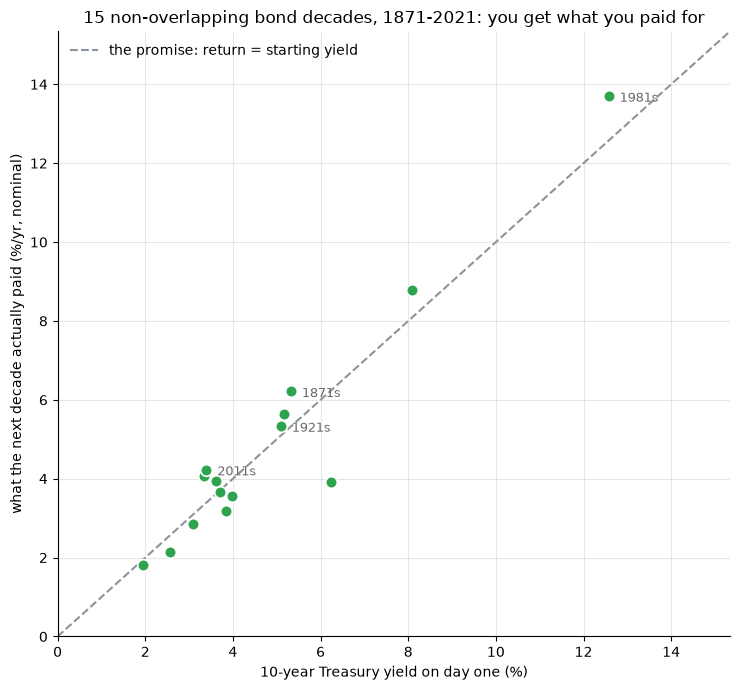

R2 = 0.923   |   average miss of the naive rule: 0.64 pp/yr


In [2]:
if HAVE_REAL:
    x, y = DEC['gs10']*100, DEC['fwd10']*100
    fig, ax = plt.subplots(figsize=(7.5, 7))
    lim = (0, max(x.max(), y.max())*1.12)
    ax.plot(lim, lim, '--', color=GREY, lw=1.5, label='the promise: return = starting yield')
    ax.scatter(x, y, s=70, color=GREEN, zorder=3, edgecolor='white', linewidth=1.2)
    for d, xi, yi in zip(DEC.index, x, y):
        if d.year in (1871, 1921, 1981, 2011):   # selective labels only
            ax.annotate(str(d.year) + 's', (xi, yi), textcoords='offset points',
                        xytext=(8, -4), fontsize=9, color='dimgray')
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel('10-year Treasury yield on day one (%)')
    ax.set_ylabel('what the next decade actually paid (%/yr, nominal)')
    ax.set_title('15 non-overlapping bond decades, 1871-2021: you get what you paid for')
    ax.legend(loc='upper left', frameon=False)
    plt.tight_layout(); plt.show()
    print(f"R2 = {R['r2']}   |   average miss of the naive rule: {R['mae_pp']} pp/yr")
else:
    print('cache missing - frozen headline: R2 =', R['r2'], ', MAE =', R['mae_pp'], 'pp/yr')

Fifteen dots, one ruler. R² = **0.923** — the starting yield explains ~92% of everything that happened to bond investors across a century and a half that included two world wars, the Great Depression, the 1970s inflation, and the zero-rate 2010s.

> 🔬 **For the quants.** Slope t = +12.5, slope statistically indistinguishable from 1, intercept from 0, and the result survives all 120 possible anchor months (worst R² 0.865) — see [02_for_the_quants](02_for_the_quants.ipynb).

## Why this is arithmetic, not magic

A bond portfolio that keeps its maturity near 10 years lives on a **see-saw**:

- If yields **fall** after you buy, your old bonds jump in price (nice!) — but every coupon and every maturing bond now **reinvests at worse rates**.
- If yields **rise**, your bonds get marked down (ouch) — but everything reinvests at **better rates**.

Over ~10 years the two effects **cancel almost exactly**, and what's left is… the yield you started with. Bond mathematicians call it *duration targeting convergence* (Leibowitz): a duration-D portfolio's return converges to its starting yield after about 2×D−1 years. The market can delay the payment; it can't change the bill.

That's why this is the rare "prediction" that needs no crystal ball — the number is printed on the ticket when you board.

## The 2020 buyer — a prediction of misery, delivered on schedule

December 2020: the 10-year yield averaged **0.93%** — the worst starting hand in 150 years of data. The rule's forecast was brutal and public: *your decade will pay about 0.93% a year, nominal, before inflation.* Then 2022 happened — the worst bond crash in modern history. Did it break the rule?

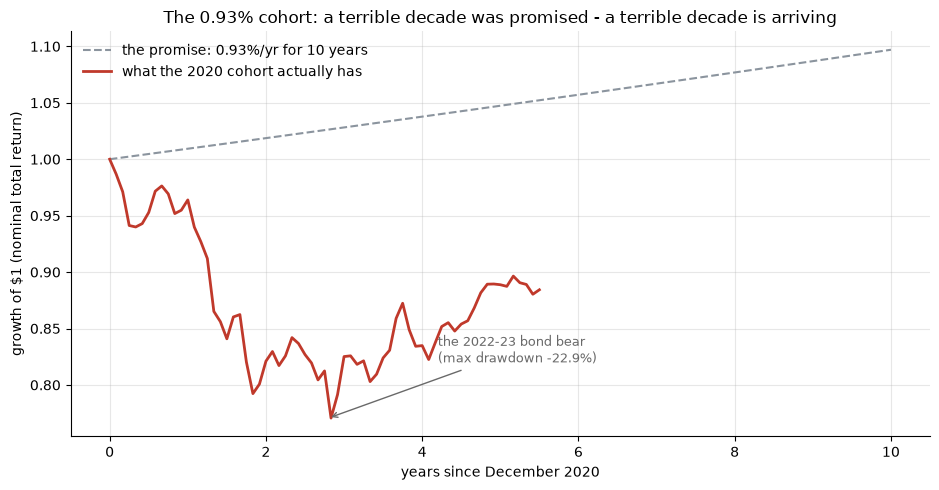

realised so far (5.5y): -2.21%/yr | needs +4.91%/yr over the remaining years to land exactly on the promise


In [3]:
if HAVE_REAL:
    seg = PANEL['tr'].loc['2020-12-01':]
    seg = seg / seg.iloc[0]
    yrs = np.arange(len(seg)) / 12
    promise = (1 + R['c_y0']/100) ** np.arange(0, 10.01, 1/12)
    fig, ax = plt.subplots()
    ax.plot(np.arange(len(promise))/12, promise, '--', color=GREY, lw=1.5,
            label=f"the promise: {R['c_y0']}%/yr for 10 years")
    ax.plot(yrs, seg.values, color=RED, lw=2, label='what the 2020 cohort actually has')
    ax.annotate('the 2022-23 bond bear\n(max drawdown -22.9%)',
                xy=(2.8, seg.min()), xytext=(4.2, 0.82), fontsize=9, color='dimgray',
                arrowprops=dict(arrowstyle='->', color='dimgray'))
    ax.set_xlabel('years since December 2020')
    ax.set_ylabel('growth of $1 (nominal total return)')
    ax.set_title('The 0.93% cohort: a terrible decade was promised - a terrible decade is arriving')
    ax.legend(frameon=False); plt.tight_layout(); plt.show()
    print(f"realised so far ({R['c_years']}y): {R['c_realized']}%/yr | "
          f"needs +{R['c_required']}%/yr over the remaining years to land exactly on the promise")
else:
    print('cache missing - frozen: realised', R['c_realized'], '%/yr, max DD', R['c_dd'], '%')

Here's the subtle part: the crash is **not a failure of the rule — it's the mechanism**. The cohort is 5½ years in at **−2.2%/yr**, and to finish exactly on the promised 0.93%/yr it needs about **+4.91%/yr** for the remaining years — which is roughly what yields *are* after the crash. The see-saw is pulling the cohort back to its ticket price. The 2020 lesson isn't "bonds are unpredictable"; it's the opposite: **the misery was printed on the ticket**, and people bought anyway.

## Does the same trick work for stocks? (No.)

Stocks have a "starting yield" too — the earnings yield (1/CAPE). Run the exact same experiment: starting earnings yield vs the next decade of stock returns.

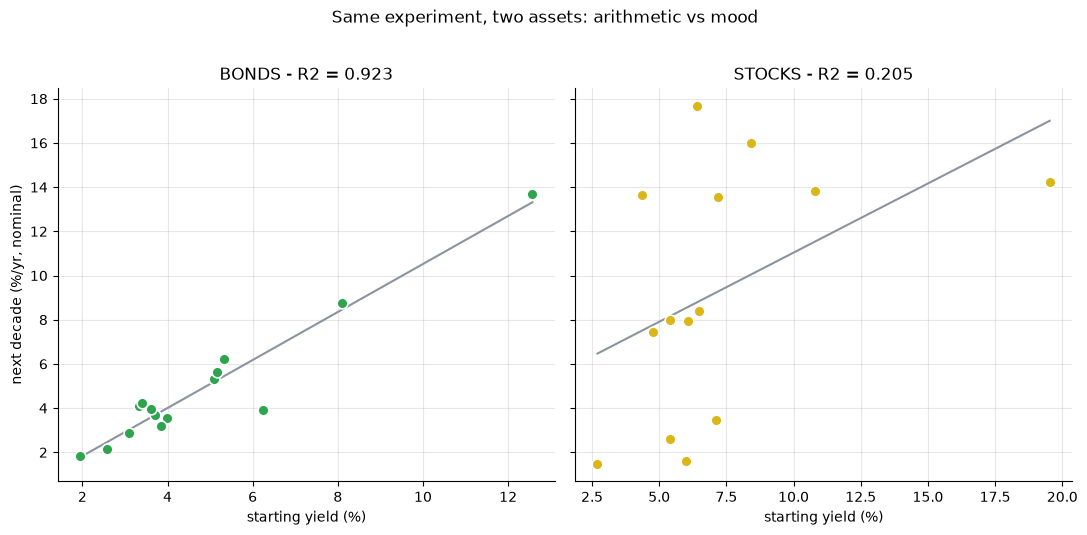

average miss of 'return = starting yield': bonds 0.64 pp/yr vs stocks 4.57 pp/yr


In [4]:
if HAVE_REAL:
    stk = data.load_stock_decades()
    sdec = st.decade_table(stk, xcol='ey', ycol='fwd10', phase=0)
    fig, axes = plt.subplots(1, 2, figsize=(11, 5.2), sharey=True)
    for ax, tab, xc, ttl, col, r2 in [
        (axes[0], DEC, 'gs10', f"BONDS - R2 = {R['r2']}", GREEN, R['r2']),
        (axes[1], sdec, 'ey', f"STOCKS - R2 = {R['s_r2']}", AMBER, R['s_r2'])]:
        x, y = tab[xc]*100, tab['fwd10']*100
        b, a = np.polyfit(x, y, 1)
        xs = np.linspace(x.min(), x.max(), 50)
        ax.scatter(x, y, s=60, color=col, edgecolor='white', linewidth=1.2, zorder=3)
        ax.plot(xs, a + b*xs, '-', color=GREY, lw=1.5)
        ax.set_title(ttl); ax.set_xlabel('starting yield (%)')
    axes[0].set_ylabel('next decade (%/yr, nominal)')
    fig.suptitle('Same experiment, two assets: arithmetic vs mood', y=1.02)
    plt.tight_layout(); plt.show()
    print(f"average miss of 'return = starting yield': bonds {R['mae_pp']} pp/yr vs stocks {R['s_mae']} pp/yr")
else:
    print('cache missing - frozen: bonds R2', R['r2'], 'vs stocks R2', R['s_r2'])

For stocks the dots scatter everywhere: R² = **0.205**, and the naive rule misses by **4.57 points a year** — seven times the bond error. A bond is a *contract* (fixed coupons, fixed principal — the yield mechanically becomes your return); a stock is a *claim on moods and profits*. The repaired stock version — subtract the bond yield from the earnings yield first — is its own study on this bench: **[120 — Excess-CAPE-Yield](../../120-excess-cape-yield/README.md)** (R² 0.70, a statistical pattern, *not* an identity).

**Busted** on the stock side — the arithmetic belongs to bonds.

## The fine print (read this before you feel too safe)

1. **It's a *nominal* lock.** Rerun everything against inflation-adjusted returns and R² collapses from 0.923 to **0.239**. The 1940s and 1970s cohorts collected every promised coupon and still lost purchasing power. The ticket price is in dollars, not in groceries.
2. **It's beta, not alpha.** Knowing your decade in advance is priceless for *planning* (retirement ladders, liability matching) — but it beats nobody; everyone can read the same yield.
3. **One country's tape.** The US never defaulted in-sample. A 1913 buyer of Russian bonds also "knew his decade."

## Verdict

| Axis | Stamp |
|---|---|
| Does the starting yield pin the bond decade? | **REAL** — R² 0.923, slope ≈ 1, 155 years, robust everywhere we poked |
| Can you deploy it? | **INVESTABLE** — one Treasury purchase, ~0 cost, unlimited capacity; but it locks *nominal* dollars only |
| Works for stocks too? | **BUSTED** — R² 0.205; see [study 120](../../120-excess-cape-yield/README.md) |

*Full stats, anchor sweep, HAC regression and the synthetic control: [02_for_the_quants.ipynb](02_for_the_quants.ipynb). Reproducible run: [docs/results.md](../docs/results.md). Not investment advice.*